# Telco Customer Churn — Exploratory Data Analysis

End-to-end EDA for the WA_Fn-UseC_-Telco-Customer-Churn dataset.  
Target: `Churn` (binary classification — Yes / No)

## 1. Overview

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

from data.loader import load_csv

df = load_csv()

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns and dtypes:")
print(df.dtypes.to_string())
df.head()

Loaded: C:\Users\jeged\Downloads\Data-Science-Project\Customer Churn Prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: 7,043 rows x 21 columns

Columns and dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Target Analysis

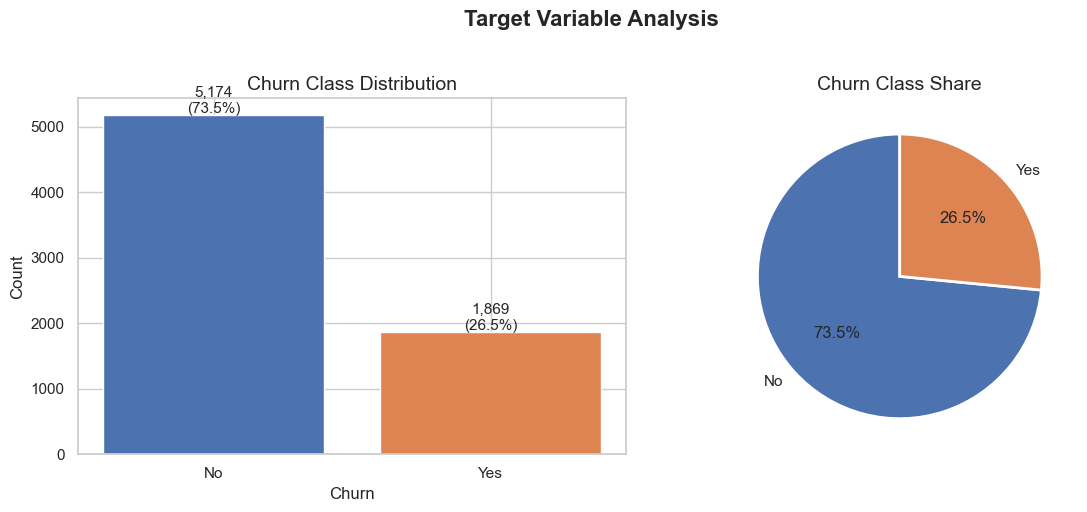

In [2]:
TARGET = "Churn"
TASK = "classification"  # change to "regression" if target is continuous

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if TASK == "classification":
    counts = df[TARGET].value_counts()
    pcts = df[TARGET].value_counts(normalize=True) * 100

    axes[0].bar(counts.index, counts.values, color=["#4c72b0", "#dd8452"], edgecolor="white")
    for i, (val, pct) in enumerate(zip(counts.values, pcts.values)):
        axes[0].text(i, val + 30, f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=11)
    axes[0].set_title("Churn Class Distribution", fontsize=14)
    axes[0].set_xlabel("Churn")
    axes[0].set_ylabel("Count")

    axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
                colors=["#4c72b0", "#dd8452"], startangle=90,
                wedgeprops={"edgecolor": "white", "linewidth": 2})
    axes[1].set_title("Churn Class Share", fontsize=14)

else:  # regression
    axes[0].hist(df[TARGET].dropna(), bins=40, color="#4c72b0", edgecolor="white")
    axes[0].set_title(f"{TARGET} Distribution", fontsize=14)
    axes[0].set_xlabel(TARGET)
    axes[0].set_ylabel("Frequency")

    stats = df[TARGET].describe()
    axes[1].axis("off")
    stat_text = "\n".join([f"{k}: {v:.2f}" for k, v in stats.items()])
    axes[1].text(0.3, 0.5, stat_text, fontsize=12, va="center", family="monospace")
    axes[1].set_title("Summary Statistics", fontsize=14)

plt.suptitle("Target Variable Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Missing Values

Columns with nulls: 1 / 21
              count   pct
TotalCharges     11  0.16


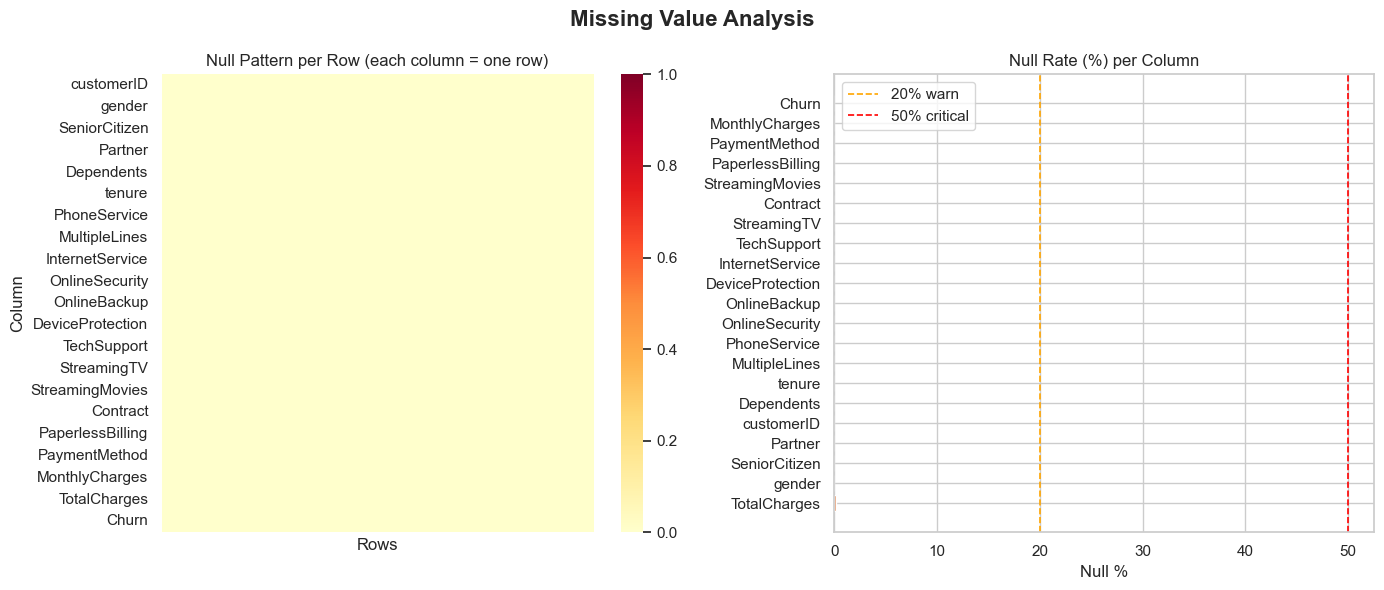

In [3]:
# Treat empty strings as nulls for TotalCharges
df_null = df.copy()
df_null["TotalCharges"] = pd.to_numeric(df_null["TotalCharges"].astype(str).str.strip(), errors="coerce")

null_counts = df_null.isnull().sum()
null_pct = (null_counts / len(df_null) * 100).round(2)
null_summary = pd.DataFrame({"count": null_counts, "pct": null_pct}).sort_values("pct", ascending=False)

print(f"Columns with nulls: {(null_counts > 0).sum()} / {len(null_counts)}")
print(null_summary[null_summary["count"] > 0].to_string())

# Heatmap — show all columns to reveal patterns even with low null rates
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

null_matrix = df_null.isnull().astype(int)
sns.heatmap(null_matrix.T, cmap="YlOrRd", cbar=True, yticklabels=True,
            xticklabels=False, linewidths=0, ax=axes[0])
axes[0].set_title("Null Pattern per Row (each column = one row)", fontsize=12)
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("Column")

axes[1].barh(null_summary.index, null_summary["pct"], color="#dd8452", edgecolor="white")
axes[1].axvline(x=20, color="orange", linestyle="--", linewidth=1.2, label="20% warn")
axes[1].axvline(x=50, color="red", linestyle="--", linewidth=1.2, label="50% critical")
axes[1].set_title("Null Rate (%) per Column", fontsize=12)
axes[1].set_xlabel("Null %")
axes[1].legend()

plt.suptitle("Missing Value Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Feature Distributions

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


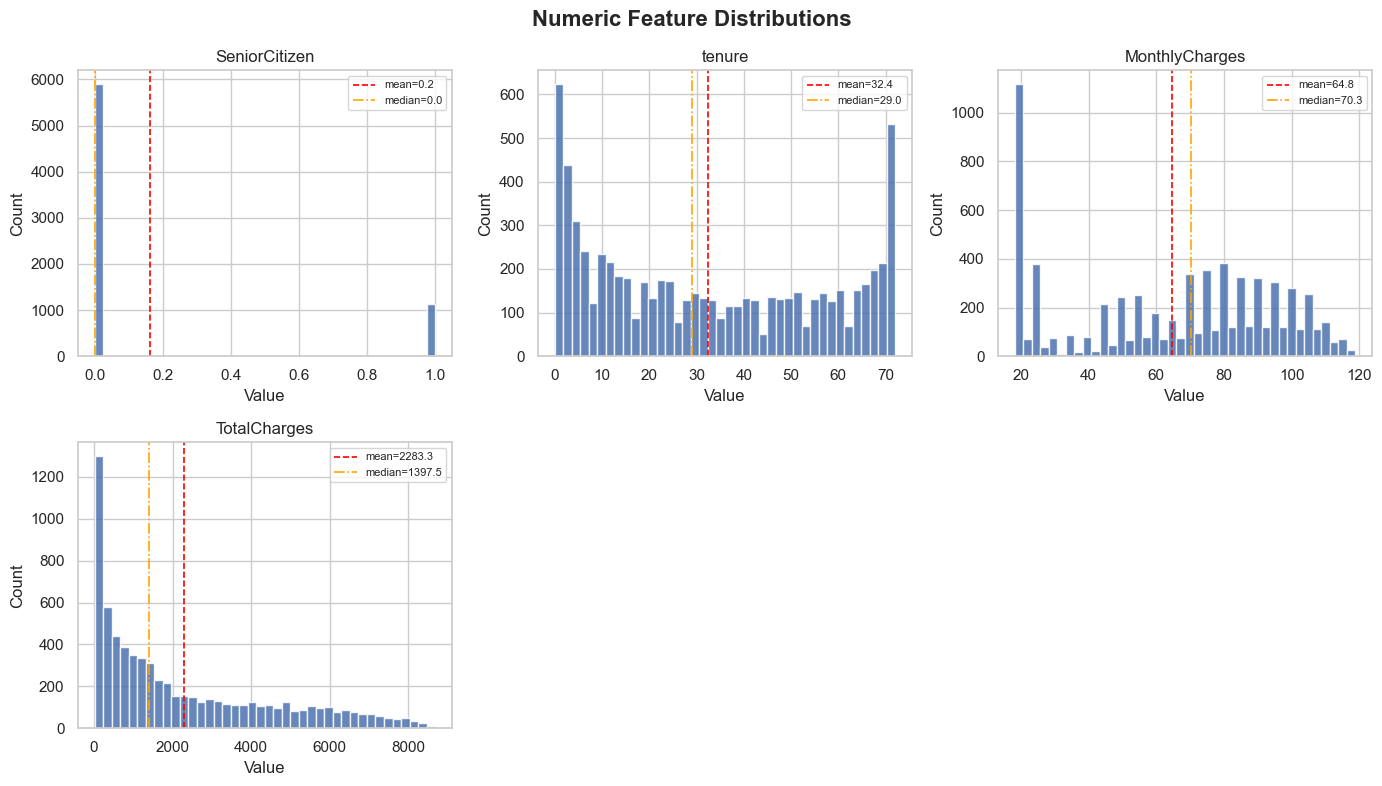

In [4]:
numeric_cols = df_null.select_dtypes(include="number").columns.tolist()
print(f"Numeric features: {numeric_cols}")

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df_null[col].dropna()
    axes[i].hist(data, bins=40, color="#4c72b0", edgecolor="white", alpha=0.85)
    axes[i].axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={data.mean():.1f}")
    axes[i].axvline(data.median(), color="orange", linestyle="-.", linewidth=1.2, label=f"median={data.median():.1f}")
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

# Hide unused axes
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Correlation Matrix

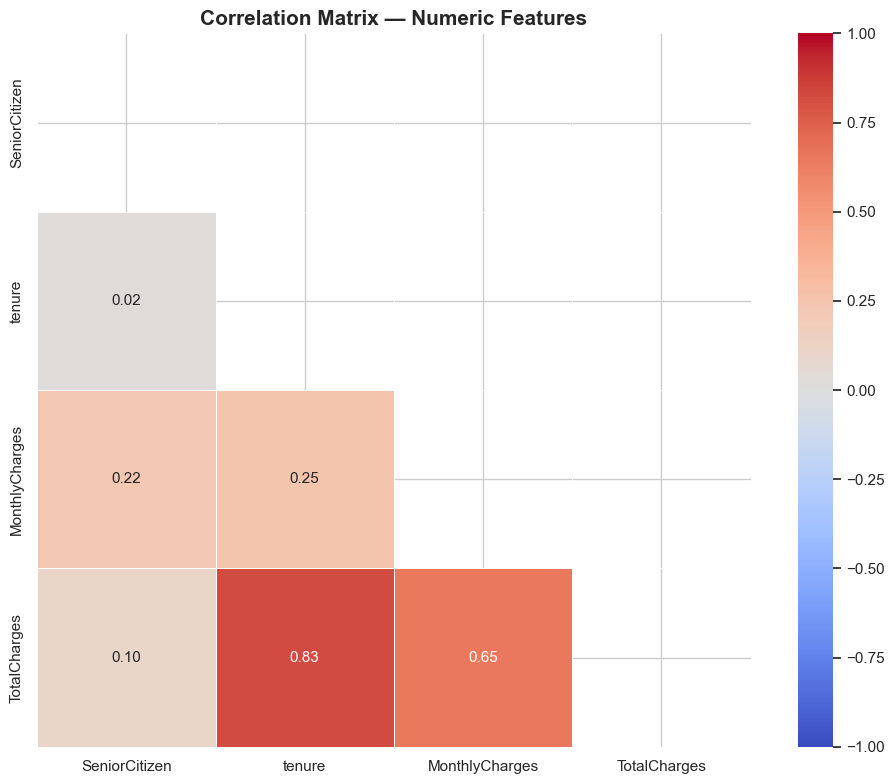


Top feature correlations:
     feature_a      feature_b  correlation
  TotalCharges         tenure     0.825880
  TotalCharges MonthlyCharges     0.651065
MonthlyCharges         tenure     0.247900
MonthlyCharges  SeniorCitizen     0.220173
  TotalCharges  SeniorCitizen     0.102411
        tenure  SeniorCitizen     0.016567


In [5]:
corr = df_null[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    annot_kws={"size": 11},
)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Print the top correlated pairs
corr_unstacked = (
    corr.where(~mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "correlation"})
    .sort_values("correlation", key=abs, ascending=False)
)
print("\nTop feature correlations:")
print(corr_unstacked.head(10).to_string(index=False))

## 6. Features vs Target

Top 3 features by correlation with target: ['tenure', 'TotalCharges', 'MonthlyCharges']


C:\Users\jeged\AppData\Local\Temp\ipykernel_336720\1621616255.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=TARGET, y=col, palette=palette, ax=axes[i],
C:\Users\jeged\AppData\Local\Temp\ipykernel_336720\1621616255.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=TARGET, y=col, palette=palette, ax=axes[i],
C:\Users\jeged\AppData\Local\Temp\ipykernel_336720\1621616255.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=TARGET, y=col, palette=palette, ax=axes[i],


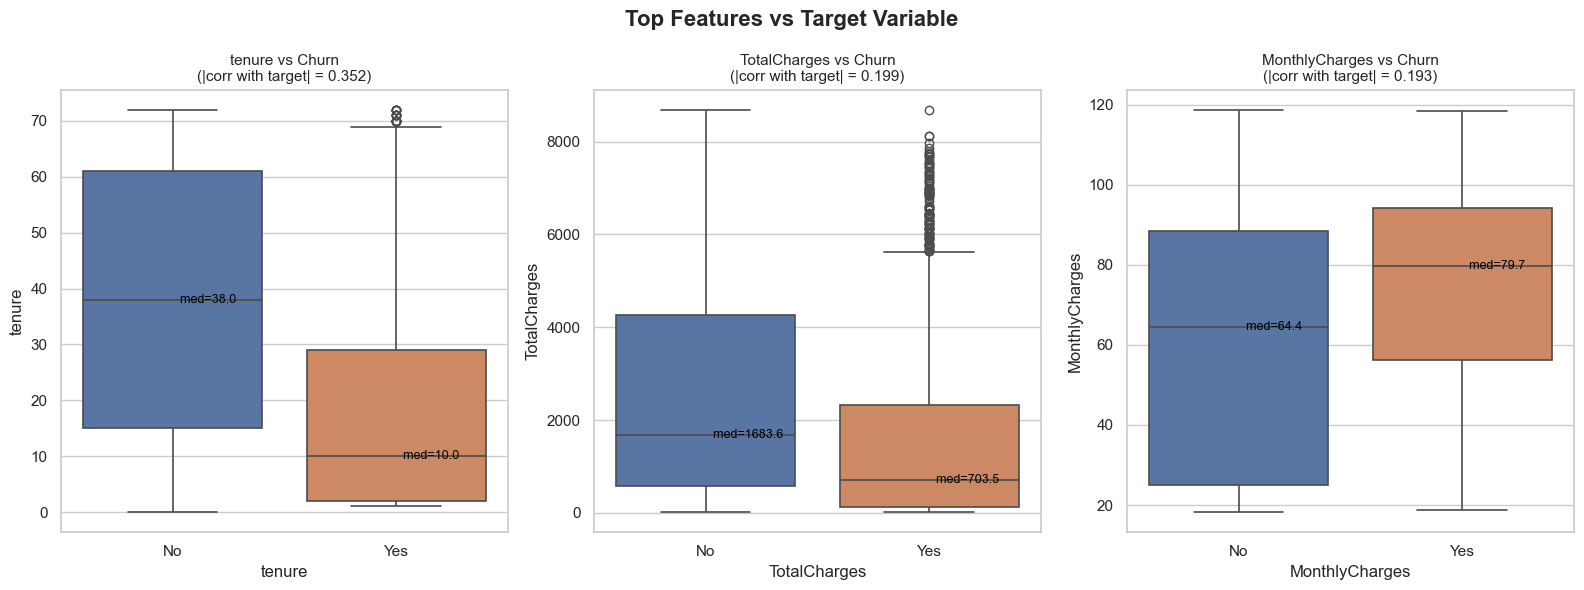

In [6]:
df_plot = df_null.copy()
df_plot[TARGET] = df_plot[TARGET].astype(str)

# Rank features by how strongly they separate the target classes
feature_candidates = [c for c in numeric_cols if c != TARGET]
target_encoded = (df_plot[TARGET] == "Yes").astype(int)
correlations = {col: abs(df_plot[col].corr(target_encoded)) for col in feature_candidates}
top_features = sorted(correlations, key=correlations.get, reverse=True)[:3]

print(f"Top 3 features by correlation with target: {top_features}")

palette = {"Yes": "#dd8452", "No": "#4c72b0"}
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(top_features):
    if TASK == "classification":
        sns.boxplot(data=df_plot, x=TARGET, y=col, palette=palette, ax=axes[i],
                    order=["No", "Yes"], linewidth=1.2)
        medians = df_plot.groupby(TARGET)[col].median()
        for j, cls in enumerate(["No", "Yes"]):
            axes[i].text(j, medians[cls], f"  med={medians[cls]:.1f}",
                         va="center", fontsize=9, color="black")
    else:
        for label, group in df_plot.groupby(TARGET):
            axes[i].scatter(group[col], group[TARGET], alpha=0.3, label=label,
                            color=palette.get(str(label), "gray"), s=15)
        axes[i].set_ylabel(TARGET)
        axes[i].legend()

    corr_val = correlations[col]
    axes[i].set_title(f"{col} vs {TARGET}\n(|corr with target| = {corr_val:.3f})", fontsize=11)
    axes[i].set_xlabel(col)

plt.suptitle("Top Features vs Target Variable", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Key Findings

- **Class imbalance:** ~26.5% of customers churned vs 73.5% retained — moderate imbalance that warrants class weighting or SMOTE during training.
- **Tenure is the strongest predictor:** churners have a median tenure of ~10 months vs ~38 months for retained customers, suggesting early-lifecycle customers are highest risk.
- **Monthly charges drive churn:** customers who churn pay significantly higher monthly charges (median ~$79) compared to those who stay (~$65), indicating price sensitivity.
- **TotalCharges has 11 disguised nulls:** rows where `TotalCharges` is an empty string correspond to customers with `tenure = 0` (new customers with no bill yet) — these should be imputed to 0 rather than dropped.
- **Strong multicollinearity:** `tenure` and `TotalCharges` are highly correlated (r ≈ 0.83), so including both in a linear model may cause instability — consider dropping `TotalCharges` or using regularisation.